In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk

from tqdm import trange
from nltk import tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from sklearn. import  

In [2]:
data = pd.read_csv('tripadvisor_hotel_reviews.csv')
data.head(10)

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
5,love monaco staff husband stayed hotel crazy w...,5
6,"cozy stay rainy city, husband spent 7 nights m...",5
7,"excellent staff, housekeeping quality hotel ch...",4
8,"hotel stayed hotel monaco cruise, rooms genero...",5
9,excellent stayed hotel monaco past w/e delight...,5


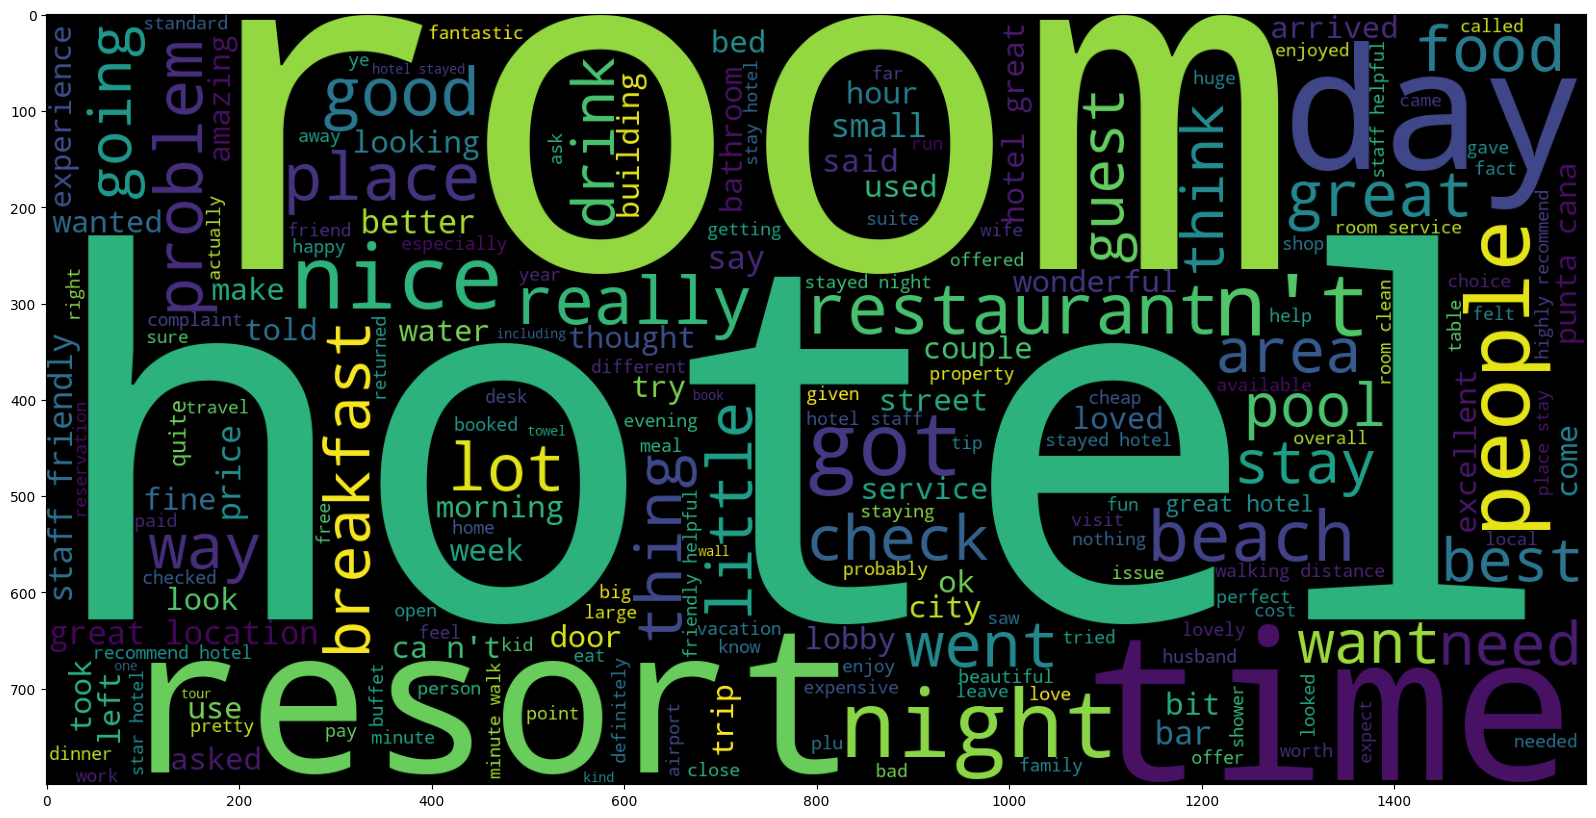

In [3]:
from wordcloud import WordCloud
text = " ".join(rev for rev in data['Review'])
wordcloud = WordCloud(
    width=1600,
    height=800,
).generate(text)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud)
plt.show()

In [4]:
data['Rating'].value_counts

<bound method IndexOpsMixin.value_counts of 0        4
1        2
2        3
3        5
4        5
        ..
20486    5
20487    4
20488    2
20489    1
20490    2
Name: Rating, Length: 20491, dtype: int64>

In [5]:
# rating 4, 5 => Positive; 1, 2, 3 => Negative
def ratings(rating):
    if rating>3 and rating<=5:
        return "Positive"
    if rating>0 and rating<=3:
        return "Negative"

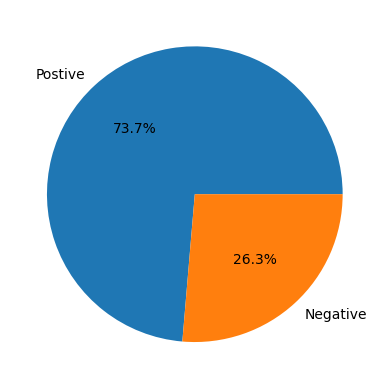

In [6]:
data['Ratings'] = data['Rating'].apply(ratings)
plt.pie(data['Ratings'].value_counts(), labels=['Postive','Negative'], autopct='%1.1f%%')
plt.show()

In [7]:
print(data['Review'][0])

nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  


In [8]:
data['Length'] = data['Review'].str.len()
data.head()

,Review,Rating,Ratings,Length
0,nice hotel expensive parking got good deal sta...,4,Positive,593
1,ok nothing special charge diamond member hilto...,2,Negative,1689
2,nice rooms not 4* experience hotel monaco seat...,3,Negative,1427
3,"unique, great stay, wonderful time hotel monac...",5,Positive,600
4,"great stay great stay, went seahawk game aweso...",5,Positive,1281


In [9]:
def word_count(review):
    review_list = review.split()
    return len(review_list)

In [10]:
data['Word_count'] = data['Review'].apply(word_count)
data.head(2)

,Review,Rating,Ratings,Length,Word_count
0,nice hotel expensive parking got good deal sta...,4,Positive,593,87
1,ok nothing special charge diamond member hilto...,2,Negative,1689,250


In [3]:
import re
def clean(review):
    review = review.lower()
    review = re.sub('[^a-z A-Z 0-9-]+','',review)
    return review

In [4]:
data['Review'] = data["Review"].apply(clean)
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4 experience hotel monaco seatt...,3
3,unique great stay wonderful time hotel monaco ...,5
4,great stay great stay went seahawk game awesom...,5


In [5]:
cor = []
for i in range(len(data['Review'])):
    cor += data['Review'][i]
print(len(cor))

    

14506409


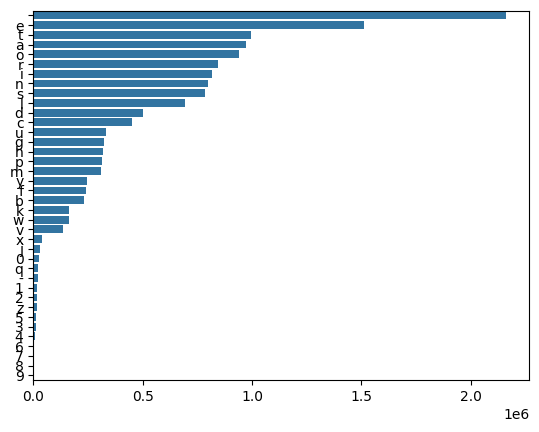

In [6]:
mostCommon = Counter(cor).most_common()
words,freq = [],[]
for word,count in mostCommon:
    words.append(word)
    freq.append(count)
sns.barplot(x=freq,y=words)
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [11]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

In [12]:
print(pd.Series(y_train).value_counts())

9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64


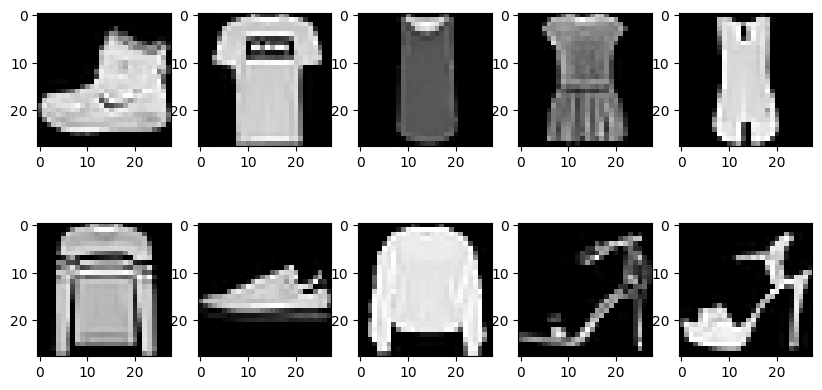

In [13]:
def plot_sample_images(x,y=None,num_samples=10):
    plt.figure(figsize=(10,5))
    for i in range(num_samples):
        plt.subplot(2,5,i+1)
        plt.imshow(x[i],cmap='gray')
    plt.show()
plot_sample_images(x_train,y_train)

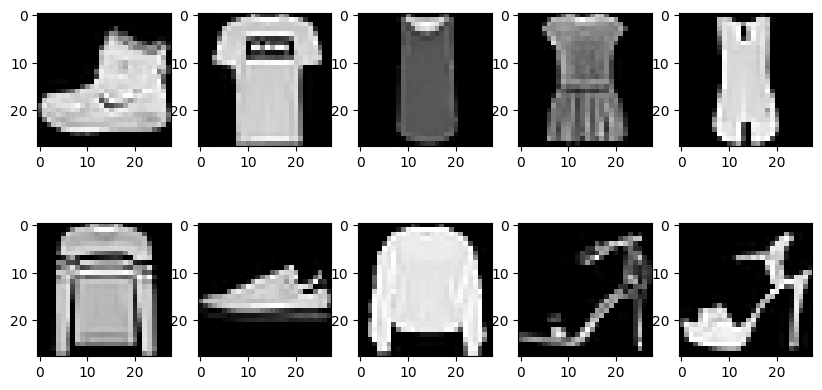

In [14]:
x_train = x_train / 255.0
x_test = x_test/255.0
plot_sample_images(x_train,y_train)

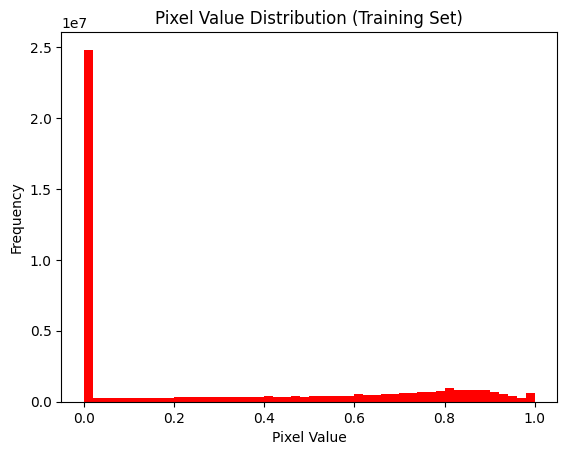

In [16]:
# Flatten the images and plot the pixel value distribution
plt.hist(x_train.flatten(), bins=50, color='red')
plt.title('Pixel Value Distribution (Training Set)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()


In [29]:
# Mean and standard deviation of pixel values
mean_pixel_value = x_train.mean()
std_pixel_value = x_train.std()

print(f"Mean pixel value: {mean_pixel_value:.2f}")
print(f"Standard deviation of pixel values: {std_pixel_value:.2f}")


Mean pixel value: 72.94
Standard deviation of pixel values: 90.02


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
data_dir = "LAB/image1"
split_ratio = 0.8
train_datagen = ImageDataGenerator(rescale=1/255,
                                   validation_split= 1 - split_ratio)

In [3]:
train_datagen.flow_from_directory?

Signature:
train_datagen.flow_from_directory(
    directory,
    target_size=(256, 256),
    color_mode='rgb',
    classes=None,
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=None,
    save_to_dir=None,
    save_prefix='',
    save_format='png',
    follow_links=False,
    subset=None,
    interpolation='nearest',
    keep_aspect_ratio=False,
)
Docstring: <no docstring>
File:      c:\users\karth\appdata\roaming\python\python312\site-packages\keras\src\legacy\preprocessing\image.py
Type:      method

In [33]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    class_mode='binary',
    target_size=(150,150),
    subset='training')

Found 145 images belonging to 2 classes.


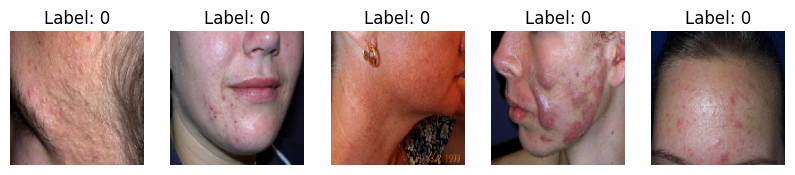

In [34]:
import matplotlib.pyplot as plt

# Get a batch of images and labels
images, labels = next(train_generator)

# Plot the first 5 images
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(f'Label: {int(labels[i])}')
    plt.axis('off')
plt.show()


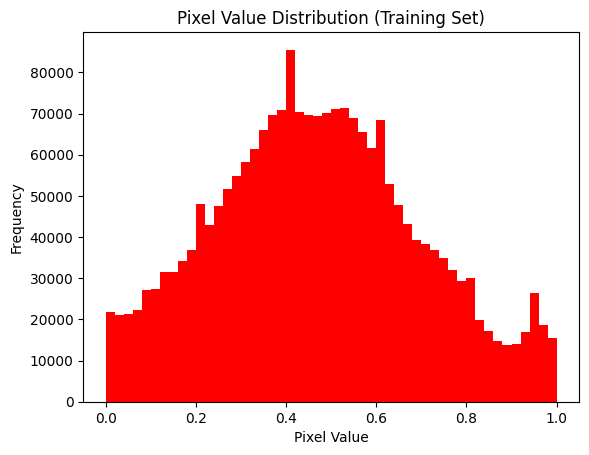

In [35]:
plt.hist(images.flatten(), bins=50, color='red')
plt.title('Pixel Value Distribution (Training Set)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()